# NN 다중분류 (흑백)
- MNIST 데이터셋

In [ ]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 8.65 s (started: 2024-07-01 00:54:34 +00:00)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras

time: 828 µs (started: 2024-07-01 00:54:43 +00:00)


## 1.데이터 준비

In [ ]:
!wget https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz

--2024-07-01 00:54:43--  https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.197.207, 74.125.135.207, 74.125.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.197.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11490434 (11M) [application/octet-stream]
Saving to: ‘mnist.npz.3’

mnist.npz.3         100%[===================>]  10.96M  --.-KB/s    in 0.07s   

2024-07-01 00:54:43 (165 MB/s) - ‘mnist.npz.3’ saved [11490434/11490434]

time: 216 ms (started: 2024-07-01 00:54:43 +00:00)


In [ ]:
mnist = np.load('mnist.npz')
mnist

NpzFile 'mnist.npz' with keys: x_test, x_train, y_train, y_test

time: 6.99 ms (started: 2024-07-01 00:54:43 +00:00)


In [ ]:
X_train = mnist['x_train']
X_test = mnist['x_test']
y_train = mnist['y_train']
y_test = mnist['y_test']

time: 306 ms (started: 2024-07-01 00:54:43 +00:00)


In [ ]:
print(X_train.shape, X_test.shape)
print(type(X_train), type(X_test))

(60000, 28, 28) (10000, 28, 28)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
time: 5.31 ms (started: 2024-07-01 00:54:44 +00:00)


In [ ]:
print(y_train.shape, y_test.shape)
print(type(y_train), type(y_test))

(60000,) (10000,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
time: 4.06 ms (started: 2024-07-01 00:54:44 +00:00)


## 2.데이터 확인

In [ ]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

time: 8.72 ms (started: 2024-07-01 00:54:44 +00:00)


In [ ]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)
sample

array([57010, 48702, 50015, 51942, 56560, 41523, 54268, 45151, 22403,
       18141, 14820, 40342,  6374, 56044,  1678, 52394, 53788, 33827,
       55820, 16198,  9914, 27890, 52309, 22299, 43585])

time: 7.89 ms (started: 2024-07-01 00:54:44 +00:00)


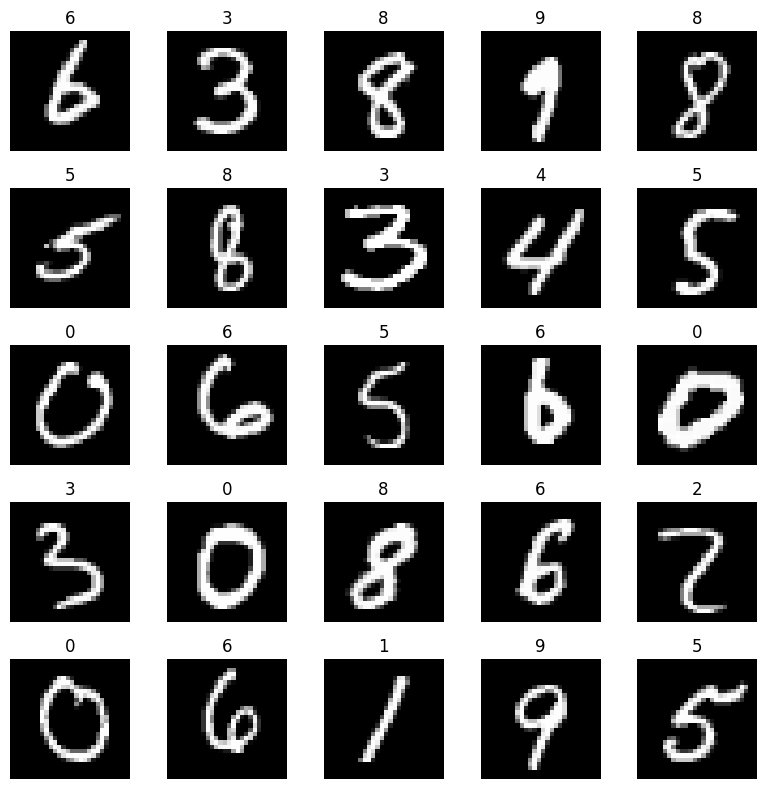

time: 3.17 s (started: 2024-07-01 00:54:44 +00:00)


In [ ]:
fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(y_train[idx])
fig.tight_layout()
plt.show()

In [ ]:
sr = pd.Series(y_train).value_counts().sort_index()
sr

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

time: 8.6 ms (started: 2024-07-01 00:54:47 +00:00)


<BarContainer object of 10 artists>

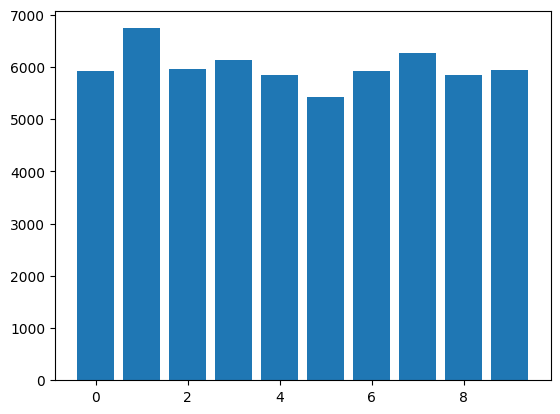

time: 243 ms (started: 2024-07-01 00:54:47 +00:00)


In [ ]:
plt.bar(sr.index, sr)

## 3.학습용, 검증용 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(48000, 28, 28) (12000, 28, 28)
(48000,) (12000,)
time: 44.8 ms (started: 2024-07-01 00:54:47 +00:00)


## 4.전처리
- X값은 스케일링
- y는 원핫인코딩

In [ ]:
# Min-Max Scaling

X_train_s = X_train / 255.
X_val_s = X_val / 255.

time: 228 ms (started: 2024-07-01 00:55:24 +00:00)


In [ ]:
# y의 원핫인코딩
from keras.utils import to_categorical

y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

time: 3.56 ms (started: 2024-07-01 00:55:27 +00:00)


In [ ]:
y_train_o.shape, y_val_o.shape

((48000, 10), (12000, 10))

time: 4.06 ms (started: 2024-07-01 00:55:55 +00:00)


In [ ]:
y_train_o[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

time: 12.1 ms (started: 2024-07-01 00:56:33 +00:00)


In [ ]:
print(X_train_s.shape, X_val_s.shape)
print(y_train_o.shape, y_val_o.shape)

(48000, 28, 28) (12000, 28, 28)
(48000, 10) (12000, 10)
time: 3.12 ms (started: 2024-07-01 00:57:49 +00:00)


## 5.모델

In [ ]:
X_train_s = X_train_s.reshape(-1, 28*28)
X_val_s = X_val_s.reshape(-1, 28*28)

time: 844 µs (started: 2024-07-01 01:02:52 +00:00)


In [ ]:
X_train_s.shape

(48000, 784)

time: 7.96 ms (started: 2024-07-01 01:03:07 +00:00)


In [ ]:
y_train_o.shape

(48000, 10)

time: 7.27 ms (started: 2024-07-01 01:04:48 +00:00)


In [ ]:
from keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

time: 238 ms (started: 2024-07-01 01:06:22 +00:00)


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 10)                170       
                                                                 
Total params: 53018 (207.10 KB)
Trainable params: 53018 (207.10 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
time: 35 ms (started: 2024-07-01 01:06:30 +00:00)


In [ ]:
adam = keras.optimizers.Adam(learning_rate=0.01)

model.compile(
    loss='categorical_crossentropy',
    optimizer=adam,
    metrics=['accuracy']
)

time: 14.8 ms (started: 2024-07-01 01:25:15 +00:00)


In [ ]:
EPOCHS = 30
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train_o,
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data = (X_val_s, y_val_o))


Epoch 1/30
1500/1500 [==============================] - 6s 3ms/step - loss: 0.3189 - accuracy: 0.9046 - val_loss: 0.2333 - val_accuracy: 0.9344
Epoch 2/30
1500/1500 [==============================] - 5s 4ms/step - loss: 0.1920 - accuracy: 0.9472 - val_loss: 0.1824 - val_accuracy: 0.9507
Epoch 3/30
1500/1500 [==============================] - 5s 3ms/step - loss: 0.1682 - accuracy: 0.9550 - val_loss: 0.1843 - val_accuracy: 0.9511
Epoch 4/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1499 - accuracy: 0.9596 - val_loss: 0.1755 - val_accuracy: 0.9561
Epoch 5/30
1500/1500 [==============================] - 6s 4ms/step - loss: 0.1363 - accuracy: 0.9647 - val_loss: 0.1581 - val_accuracy: 0.9603
Epoch 6/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1295 - accuracy: 0.9668 - val_loss: 0.1490 - val_accuracy: 0.9623
Epoch 7/30
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1189 - accuracy: 0.9694 - val_loss: 0.1566 - val_accuracy:

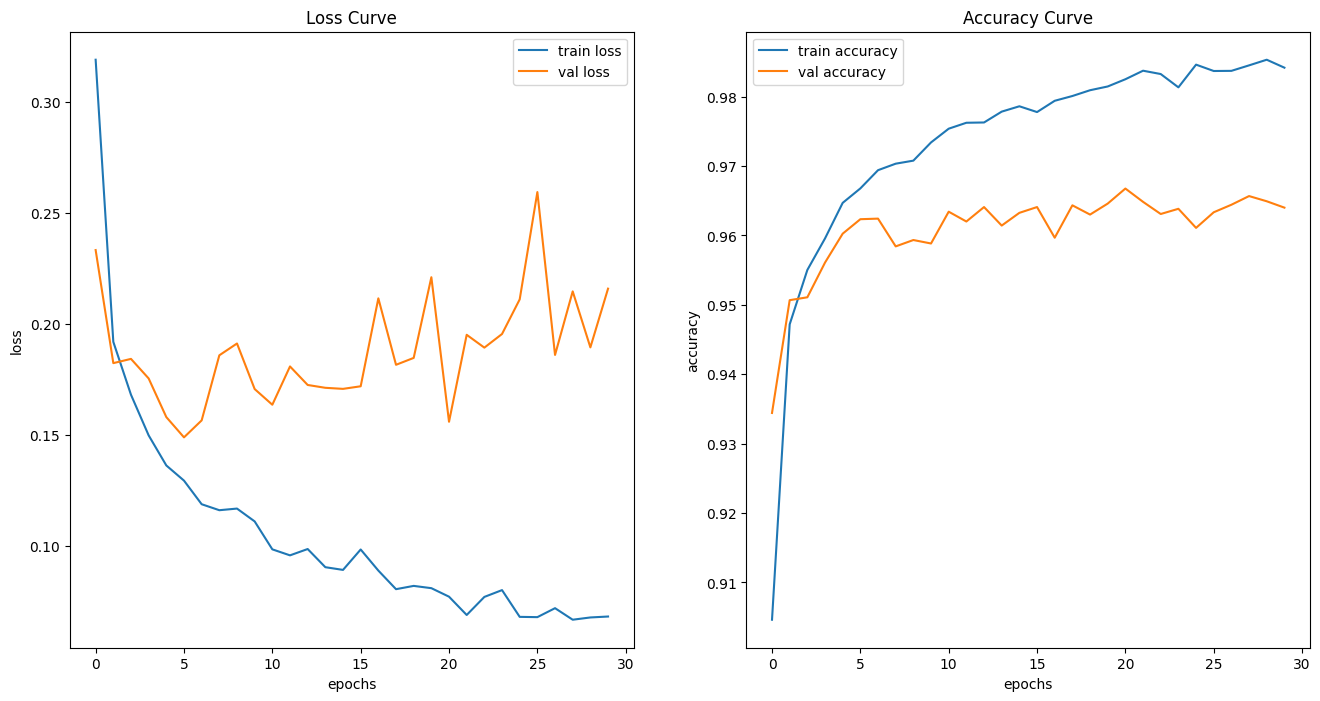

time: 874 ms (started: 2024-07-01 01:30:44 +00:00)


In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

## 6.평가

In [ ]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28*28)
y_test_o = to_categorical(y_test)

time: 29.2 ms (started: 2024-07-01 01:33:57 +00:00)


In [ ]:
X_test_s.shape, y_test_o.shape

((10000, 784), (10000, 10))

time: 14.3 ms (started: 2024-07-01 01:34:19 +00:00)


In [ ]:
y_pred = model.predict(X_test_s)

y_pred[:10]

313/313 [==============================] - 1s 3ms/step


array([[4.16904824e-24, 0.00000000e+00, 1.48616275e-09, 0.00000000e+00,
        3.45318256e-14, 0.00000000e+00, 0.00000000e+00, 9.99999940e-01,
        1.19056833e-30, 1.16538430e-12],
       [4.65659370e-15, 1.08456057e-11, 9.99999940e-01, 3.80380563e-08,
        1.15866179e-16, 1.12079275e-23, 3.19017921e-28, 2.92030914e-15,
        1.05469869e-11, 0.00000000e+00],
       [0.00000000e+00, 9.99999940e-01, 6.26721227e-21, 3.03352755e-37,
        7.55643683e-15, 1.20544627e-18, 2.47039160e-23, 1.68125757e-16,
        6.65129417e-19, 0.00000000e+00],
       [9.99999940e-01, 0.00000000e+00, 2.13385493e-16, 2.90437886e-22,
        9.90793967e-27, 5.26776164e-23, 9.47612435e-15, 9.56621066e-20,
        2.02663048e-16, 9.95244159e-36],
       [3.06231924e-16, 9.93298954e-07, 4.32313518e-09, 8.40320211e-18,
        9.97540593e-01, 8.72451533e-09, 4.24436877e-07, 2.83880439e-07,
        3.86815032e-17, 2.45746947e-03],
       [0.00000000e+00, 9.99999940e-01, 1.83739954e-25, 0.00000000e+00,
   

time: 1.6 s (started: 2024-07-01 01:34:49 +00:00)


In [ ]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

time: 7.4 ms (started: 2024-07-01 01:36:08 +00:00)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

time: 1.27 ms (started: 2024-07-01 01:36:51 +00:00)


accuracy: 0.9684
recall: 0.9681062459105167
precision: 0.9682332325766974
f1 : 0.9681019782261986


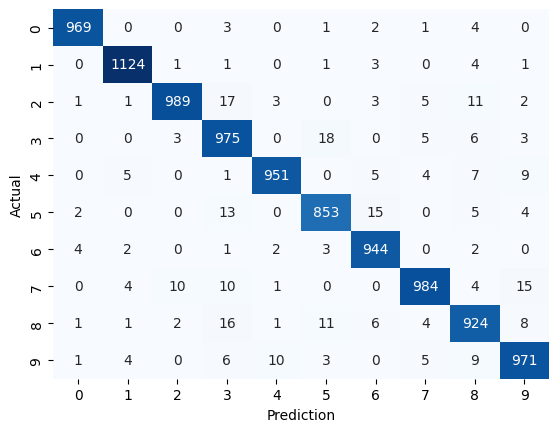

time: 692 ms (started: 2024-07-01 01:37:22 +00:00)


In [ ]:
print_metrics(y_test, y_pred, aver='macro')

In [ ]:
X_test.shape

(10000, 28, 28)

time: 4.04 ms (started: 2024-07-01 01:38:55 +00:00)


In [ ]:
sample = np.random.randint(10000, size=25)
sample

array([4218, 8958, 4389, 2327, 8004, 2931, 7777,  197, 7125, 1930, 6287,
       8800, 9339, 4282, 2511, 9986,  659, 2811, 7098, 6546, 9561, 1986,
       8338, 2911, 1734])

time: 22 ms (started: 2024-07-01 01:41:52 +00:00)


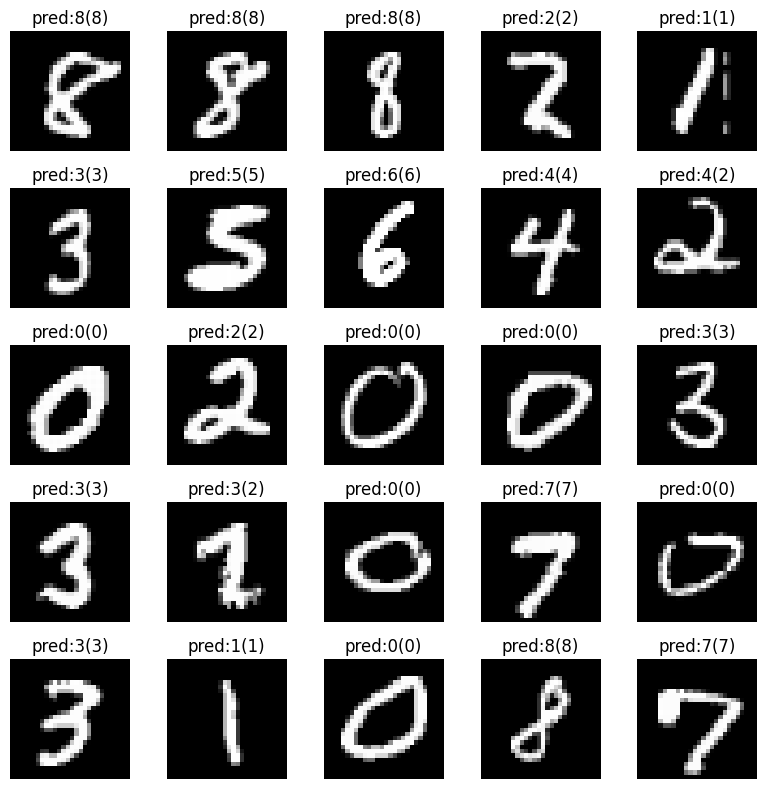

time: 2.47 s (started: 2024-07-01 01:41:54 +00:00)


In [ ]:
fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.axis('off')
    plt.title(f'pred:{y_pred[idx]}({y_test[idx]})')
fig.tight_layout()
plt.show()